# Yield Curve & Fixed Income Risk Analytics — Demo

End-to-end walkthrough: bootstrap the Treasury spot curve, calibrate Nelson-Siegel-Svensson, price a bond portfolio, and measure interest rate risk. Run the pipeline modules (or `src.data_pipeline` ... `src.report`) before this notebook so the SQLite database is populated.

In [1]:
import os, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run from the project root so relative paths resolve.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

from src.config import DB_PATH
from src.bootstrap import bootstrap_curve
from src.nss import nss_rate
print('working dir:', os.getcwd())

working dir: C:\Users\hanyx\Desktop\Finance\Risk_Quant\project_2\YieldCurve


## 1. The bootstrapped curve

Spot, forward, and discount factors on the latest date.

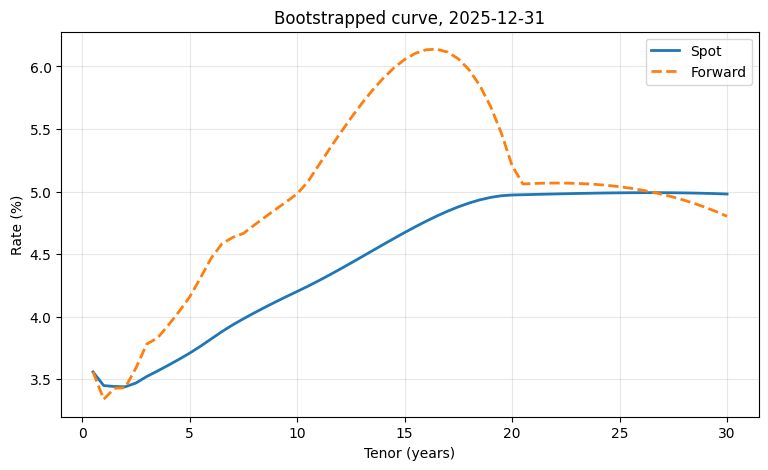

In [2]:
with sqlite3.connect(DB_PATH) as conn:
    sc = pd.read_sql('SELECT * FROM spot_curves ORDER BY date, tenor', conn)
latest = sc[sc['date'] == sc['date'].max()]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(latest['tenor'], latest['spot'] * 100, label='Spot', lw=2)
ax.plot(latest['tenor'], latest['forward'] * 100, label='Forward', lw=2, ls='--')
ax.set_xlabel('Tenor (years)'); ax.set_ylabel('Rate (%)')
ax.set_title(f"Bootstrapped curve, {latest['date'].iloc[0]}")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 2. NSS fit

The six-parameter model against the bootstrapped spots.

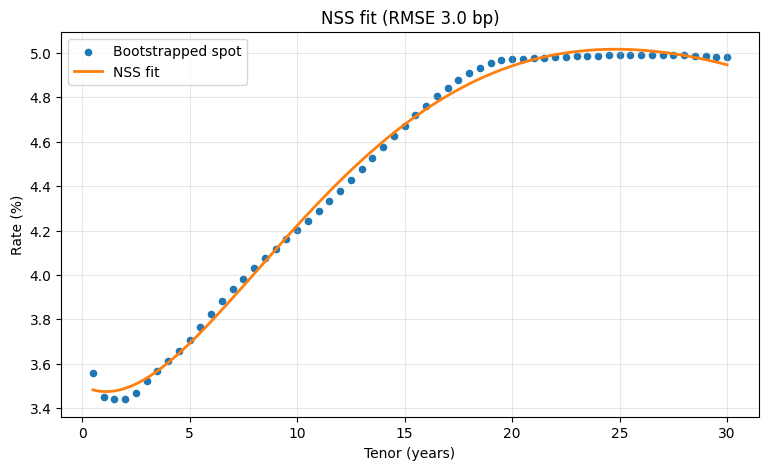

In [3]:
with sqlite3.connect(DB_PATH) as conn:
    params = pd.read_sql('SELECT * FROM nss_params ORDER BY date', conn)
theta = params.iloc[-1][['b0', 'b1', 'b2', 'b3', 'tau1', 'tau2']].values.astype(float)
grid = np.linspace(0.5, 30, 200)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(latest['tenor'], latest['spot'] * 100, s=20, label='Bootstrapped spot')
ax.plot(grid, nss_rate(grid, *theta) * 100, color='C1', lw=2, label='NSS fit')
ax.set_xlabel('Tenor (years)'); ax.set_ylabel('Rate (%)')
ax.set_title(f"NSS fit (RMSE {params.iloc[-1]['rmse'] * 1e4:.1f} bp)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 3. Bond analytics

Pricing, duration, convexity, DV01, and key rate durations.

In [4]:
with sqlite3.connect(DB_PATH) as conn:
    analytics = pd.read_sql(
        'SELECT * FROM bond_analytics WHERE date = (SELECT MAX(date) FROM bond_analytics)', conn)
cols = ['bond_id', 'price', 'ytm', 'mod_dur', 'convexity', 'dv01',
        'krd_2y', 'krd_5y', 'krd_10y', 'krd_20y', 'krd_30y']
analytics[cols].round(2)

,bond_id,price,ytm,mod_dur,convexity,dv01,krd_2y,krd_5y,krd_10y,krd_20y,krd_30y
0,CORP_10Y,1128850.40,0.04,7.90,72.04,891.36,25.62,102.96,750.91,0.00,0.00
1,CORP_5Y,1080317.65,0.04,4.46,21.36,482.28,24.50,449.55,0.00,0.00,0.00
2,UST_10Y,2011489.84,0.04,8.26,76.82,1660.61,37.87,152.21,1452.62,0.00,0.00
3,UST_10Y_STRIP,656946.06,0.04,10.00,100.00,656.95,0.00,0.00,656.62,0.00,0.00
4,UST_20Y,961853.19,0.05,13.25,225.26,1274.14,20.05,80.58,227.67,913.73,0.00
5,UST_2Y,1014943.50,0.03,1.94,3.83,196.79,190.65,0.00,0.00,0.00,0.00
6,UST_30Y,1891040.76,0.05,16.36,380.90,3093.59,40.10,161.16,455.33,659.03,1675.81
7,UST_3Y,1012708.72,0.04,2.86,8.41,289.41,191.08,92.53,0.00,0.00,0.00
8,UST_5Y,1012251.84,0.04,4.58,22.18,464.04,17.82,440.20,0.00,0.00,0.00
9,UST_7Y,1009775.90,0.04,6.16,41.11,622.08,18.27,374.23,222.90,0.00,0.00


In [5]:
# KRD additivity: the sum of key rate durations reconciles to DV01.
krd_cols = ['krd_2y', 'krd_5y', 'krd_10y', 'krd_20y', 'krd_30y']
check = analytics[['bond_id', 'dv01']].copy()
check['krd_sum'] = analytics[krd_cols].sum(axis=1)
check['rel_err_%'] = (100 * (check['dv01'] - check['krd_sum']).abs() / check['dv01']).round(3)
check.round(2)

,bond_id,dv01,krd_sum,rel_err_%
0,CORP_10Y,891.36,879.49,1.33
1,CORP_5Y,482.28,474.06,1.71
2,UST_10Y,1660.61,1642.70,1.08
3,UST_10Y_STRIP,656.95,656.62,0.05
4,UST_20Y,1274.14,1242.02,2.52
5,UST_2Y,196.79,190.65,3.12
6,UST_30Y,3093.59,2991.44,3.30
7,UST_3Y,289.41,283.62,2.00
8,UST_5Y,464.04,458.02,1.30
9,UST_7Y,622.08,615.40,1.07


## 4. Stress scenarios

Portfolio P&L by scenario; the parallel asymmetry is convexity.

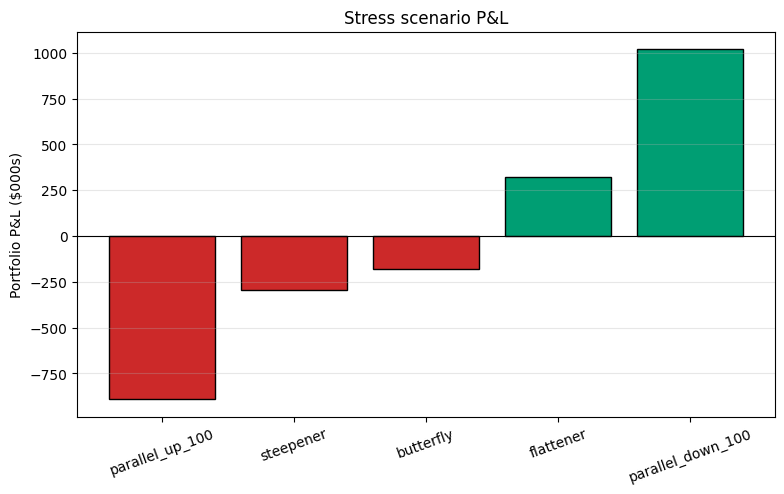

,scenario,pnl
3,parallel_up_100,-890109.0
4,steepener,-292641.0
0,butterfly,-182402.0
1,flattener,321218.0
2,parallel_down_100,1020598.0


In [6]:
with sqlite3.connect(DB_PATH) as conn:
    stress = pd.read_sql('SELECT scenario, SUM(pnl) AS pnl FROM stress_results GROUP BY scenario', conn)
stress = stress.sort_values('pnl')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#CC2929' if v < 0 else '#009E73' for v in stress['pnl']]
ax.bar(stress['scenario'], stress['pnl'] / 1e3, color=colors, edgecolor='black')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Portfolio P&L ($000s)'); ax.set_title('Stress scenario P&L')
plt.xticks(rotation=20); ax.grid(alpha=0.3, axis='y')
plt.show()
stress.assign(pnl=stress['pnl'].round(0))